In [1]:
import pandas as pd

df = pd.read_csv("cleaned_property_sales_timeseries.csv")

df.head()

,xrCompositeLandUseID,xrBuildingTypeID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,SaleDate,...,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice,SaleYear,SaleMonth,PricePerSqft,AppraisalRatio,YearMonth
0,3,6.0,77,STAFFORD ST,2,6000.0,1092.0,1.0,WRIGHT,2024-07-01 00:00:00+00:00,...,1,10,5,False,12.464587,2024,7,237.179487,1.383547,2024-07
1,3,3.0,73,STAFFORD ST,2,6000.0,936.0,1.0,SANTANA,2022-04-26 00:00:00+00:00,...,1,10,5,False,12.245298,2022,4,222.222222,1.081643,2022-04
2,3,6.0,61,STAFFORD ST,2,6000.0,1111.0,1.0,MARTINEZ,2023-12-22 00:00:00+00:00,...,1,10,5,False,11.736077,2023,12,112.511251,0.842318,2023-12
3,3,6.0,211,NEWINGTON AVE,2,5040.0,1684.0,1.0,CAHUANA FLORES,2021-01-11 00:00:00+00:00,...,1,10,5,False,12.083911,2021,1,105.106888,0.894391,2021-01
4,3,3.0,18,BRISTOL ST,2,6000.0,900.0,1.0,NEGRON,2021-09-21 00:00:00+00:00,...,1,10,5,False,12.144203,2021,9,208.888889,1.101347,2021-09


## Correlation Analysis Insight

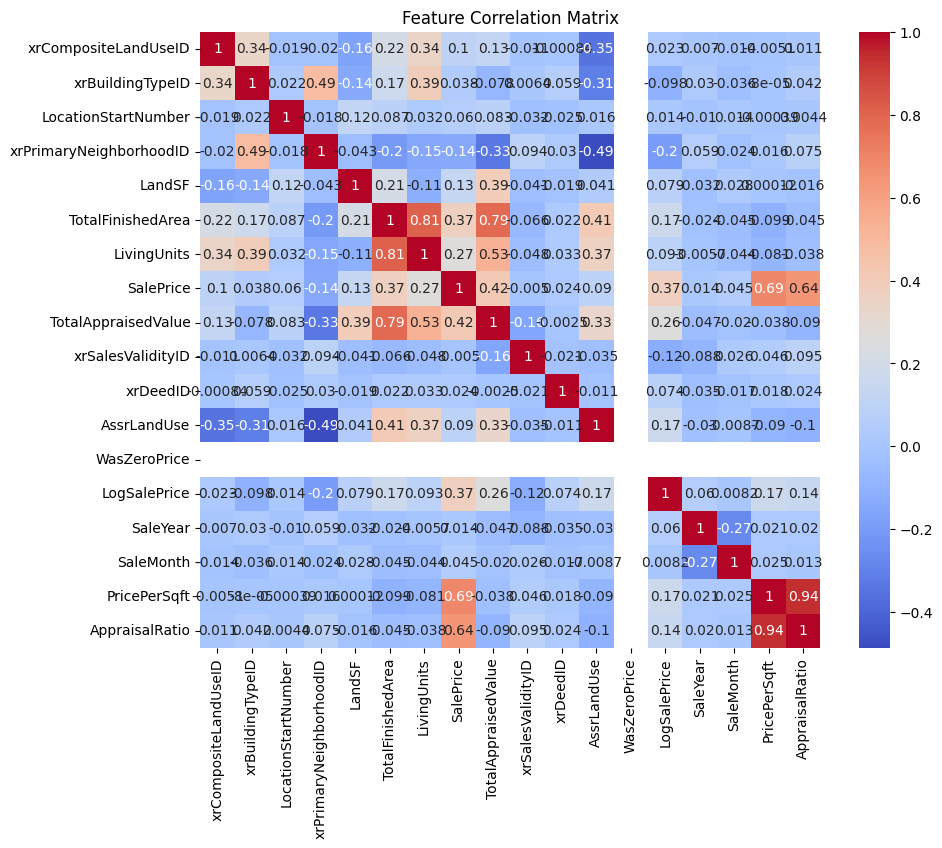

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

Correlation Analysis Insight

The correlation heatmap reveals relationships between numerical features in the property dataset.

a) PricePerSqft has a strong positive correlation with SalePrice (~0.69), indicating that properties with higher price per square foot tend to have higher overall sale prices.

b) AppraisalRatio also shows a strong positive correlation with PricePerSqft (~0.94), suggesting that appraisal values are closely aligned with property price per square foot.

c) TotalFinishedArea has a moderate positive correlation with SalePrice (~0.37), meaning larger houses generally sell for higher prices.

d) LivingUnits and TotalFinishedArea show strong correlation (~0.81), which is expected since properties with more units typically have larger finished areas.

e) Most other variables show weak or near-zero correlations, suggesting they have limited direct influence on property sale price.

Overall, the heatmap highlights property size and price-per-square-foot as the strongest drivers of sale price in this dataset.

## Feature Importance (from Random Forest)

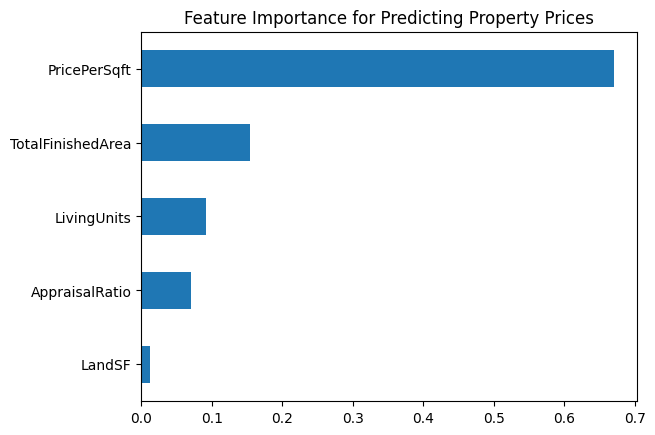

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Select features
X = df[["LandSF", "TotalFinishedArea", "LivingUnits", "PricePerSqft", "AppraisalRatio"]]
y = df["SalePrice"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance for Predicting Property Prices")
plt.show()

Feature Importance Insight

The Random Forest feature importance analysis identifies which variables contribute most to predicting property sale prices.

a) PricePerSqft is the most influential feature, contributing the majority of predictive power in the model. This indicates that the price per square foot is the strongest determinant of a property's total sale price.

b) TotalFinishedArea has the second highest importance, suggesting that larger homes with more finished area generally sell for higher prices.

c) LivingUnits has moderate importance, meaning properties with multiple living units tend to influence property valuation.

d) AppraisalRatio has a smaller but noticeable influence, indicating that appraisal-based metrics still contribute to price prediction.

e) LandSF shows very low importance, suggesting that land size alone does not strongly determine the sale price compared to building-related features.

Overall, the model highlights that property size and price-per-square-foot are the most significant factors influencing real estate prices in this dataset.

### Model Performance (R² score)

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.976764517774162
MAE: 4145.795338246506


### Predicted vs Actual Plot

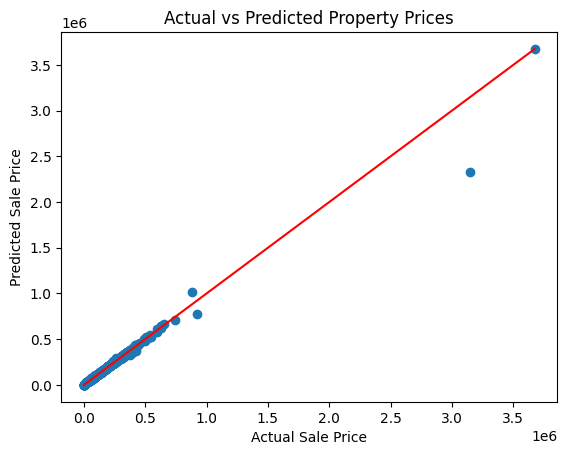

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Property Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

Model Performance Insight

The Random Forest regression model was evaluated using the R² score and Mean Absolute Error (MAE).

a) The R² score (~0.98) indicates that the model explains nearly 98% of the variance in property sale prices, showing extremely strong predictive performance.

b) The Mean Absolute Error (~4145) means that on average, the model's predicted property prices differ from the actual sale prices by around $4,100, which is relatively small compared to the overall price range.

c) The Actual vs Predicted plot shows most points closely aligned with the diagonal line, indicating that predicted values closely match the real sale prices.

d) A few deviations from the line are visible for very high-value properties, which is common in real estate datasets due to rare luxury property sales.

Overall, the model demonstrates high accuracy and reliability in predicting property sale prices based on structural and valuation features.

# Time Series Decomposition

In [30]:
df["SaleDate"] = pd.to_datetime(df["SaleDate"])
df["YearMonth"] = df["SaleDate"].dt.to_period("M")

monthly_prices = df.groupby("YearMonth")["SalePrice"].median()
monthly_prices.index = monthly_prices.index.to_timestamp()

/var/folders/hb/0y9l2hxs61s71_hjm_mdqxz00000gn/T/ipykernel_45154/179256096.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["SaleDate"].dt.to_period("M")


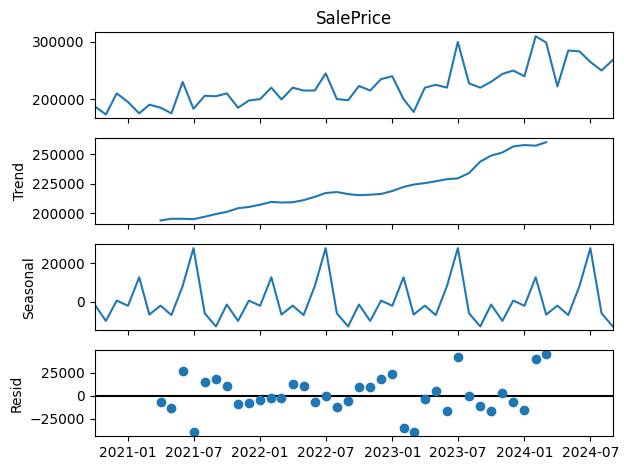

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_prices, model="additive", period=12)

decomposition.plot()
plt.show()

Time Series Decomposition Insight

The seasonal decomposition analysis separates the property price time series into trend, seasonal, and residual components.

a) Trend component:
The trend line shows a clear upward movement from 2021 to 2024, indicating a steady increase in property prices over time.

b) Seasonal component:
The seasonal pattern shows periodic fluctuations across months. Certain months consistently show slightly higher or lower prices, which may reflect seasonal real estate market activity.

c) Residual component:
The residual values represent random variations that are not explained by the trend or seasonal patterns. These fluctuations are likely due to unique property characteristics or occasional high-value transactions.

Overall, the decomposition confirms that property prices follow a strong long-term upward trend with moderate seasonal fluctuations and some irregular variations typical of real estate markets.

In [26]:
!pip install statsmodels --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.1 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


## Additional plots

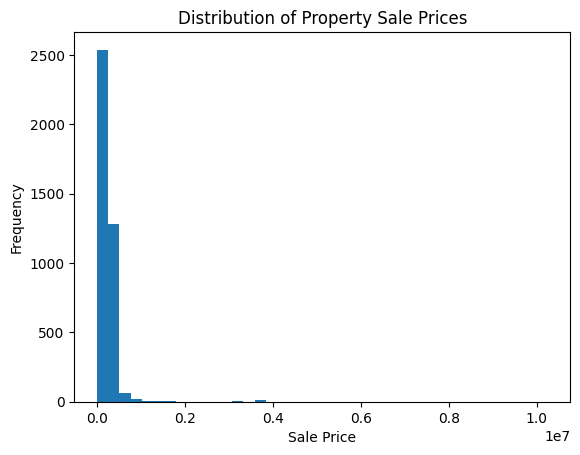

In [38]:
plt.hist(df["SalePrice"], bins=40)

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

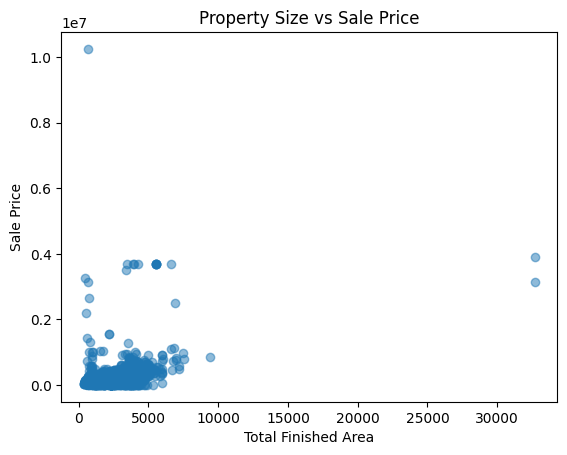

In [40]:
plt.scatter(df["TotalFinishedArea"], df["SalePrice"], alpha=0.5)

plt.xlabel("Total Finished Area")
plt.ylabel("Sale Price")
plt.title("Property Size vs Sale Price")

plt.show()

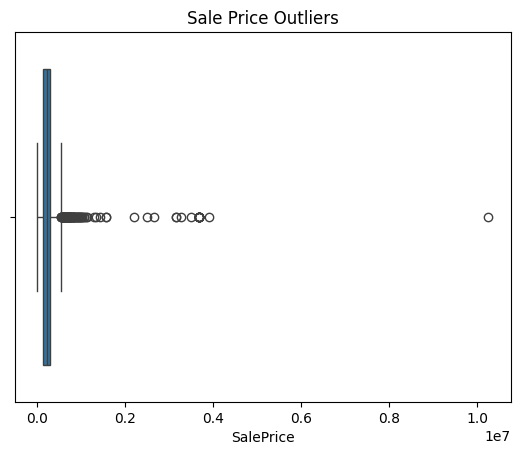

In [42]:
import seaborn as sns

sns.boxplot(x=df["SalePrice"])

plt.title("Sale Price Outliers")
plt.show()

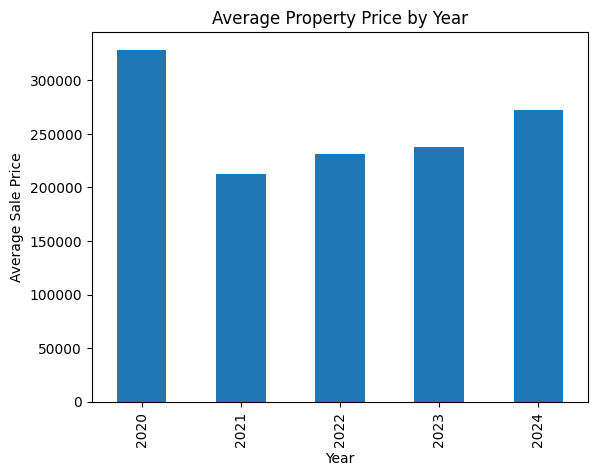

In [44]:
df.groupby("SaleYear")["SalePrice"].mean().plot(kind="bar")

plt.title("Average Property Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Sale Price")

plt.show()